# 01. Single-Cell Data Loading and Quality Control

## Objective

Load the GSE176078 breast cancer single-cell RNA-seq dataset, inspect its structure, and assess cell-level and gene-level quality-control metrics before downstream analysis.

## Main goals

1. Load single-cell gene-expression data.
2. Inspect cell and gene metadata.
3. Calculate quality-control metrics.
4. Assess genes detected per cell.
5. Assess total transcript counts per cell.
6. Assess mitochondrial gene expression.
7. Define appropriate filtering thresholds.

In [2]:
import sys

print("Python version:")
print(sys.version)

try:
    import scanpy as sc
    print("\nScanpy version:", sc.__version__)
except ImportError:
    print("\nScanpy is not installed.")

Python version:
3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]

Scanpy version: 1.12.4


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1474/1848270378.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("\nScanpy version:", sc.__version__)


In [3]:
from pathlib import Path

project_dir = Path.cwd().parent

data_dir = project_dir / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"
figures_dir = project_dir / "figures"
results_dir = project_dir / "results"

print("Project directory:", project_dir)
print("Raw data directory:", raw_dir)
print("Processed data directory:", processed_dir)

Project directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME
Raw data directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/data/raw
Processed data directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/data/processed


In [6]:
sample_dir = raw_dir / "CID4465"

print("Sample directory:", sample_dir)
print("Exists:", sample_dir.exists())

Sample directory: /Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/data/raw/CID4465
Exists: True


In [7]:
import pandas as pd
import numpy as np

print("pandas and numpy loaded.")

pandas and numpy loaded.


In [8]:
genes = pd.read_csv(
    sample_dir / "count_matrix_genes.tsv",
    sep="\t",
    header=None
)

barcodes = pd.read_csv(
    sample_dir / "count_matrix_barcodes.tsv",
    sep="\t",
    header=None
)

metadata = pd.read_csv(
    sample_dir / "metadata.csv"
)

print("Genes shape:", genes.shape)
print("Barcodes shape:", barcodes.shape)
print("Metadata shape:", metadata.shape)

print("\nGenes preview:")
display(genes.head())

print("\nBarcodes preview:")
display(barcodes.head())

print("\nMetadata preview:")
display(metadata.head())

print("\nMetadata columns:")
print(metadata.columns.tolist())

Genes shape: (29733, 1)
Barcodes shape: (1564, 1)
Metadata shape: (1564, 9)

Genes preview:


,0
0,RP11-34P13.7
1,FO538757.3
2,FO538757.2
3,AP006222.2
4,RP4-669L17.10



Barcodes preview:


,0
0,CID4465_AAACGGGTCATCGATG
1,CID4465_AAACGGGTCGGAAACG
2,CID4465_AAAGATGAGGTGTGGT
3,CID4465_AAAGCAATCCTTTACA
4,CID4465_AACCATGGTACGCTGC



Metadata preview:


,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
0,CID4465_AAACGGGTCATCGATG,CID4465,1277,799,2.662490,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
1,CID4465_AAACGGGTCGGAAACG,CID4465,478,339,3.556485,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
2,CID4465_AAAGATGAGGTGTGGT,CID4465,1495,878,3.879599,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
3,CID4465_AAAGCAATCCTTTACA,CID4465,723,457,3.181189,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
4,CID4465_AACCATGGTACGCTGC,CID4465,1977,1074,6.120384,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial



Metadata columns:
['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']


In [9]:
import scipy.io
import anndata as ad

matrix = scipy.io.mmread(
    sample_dir / "count_matrix_sparse.mtx"
)

print("Raw matrix shape:", matrix.shape)

Raw matrix shape: (29733, 1564)


/var/folders/gr/dczgzvyn4w1c3nb_7lb1vr7m0000gn/T/ipykernel_1474/2884923725.py:4: DeprecationWarning: The default value for `spmatrix` is changing to `False` in v1.20.
             That means the default return type will be a sparse array.
             Unless you use * instead of @, ** for matrix power, or you depend
             on 2D shapes from e.g. `A.sum(axis=0)` it may not matter to you.
             See the spmatrix to sparray migration guide for details.
             https://docs.scipy.org/doc/scipy/reference/sparse.migration_to_sparray.html
             
  matrix = scipy.io.mmread(


In [10]:
print("Genes shape:", genes.shape)
print("Barcodes shape:", barcodes.shape)
print("Metadata shape:", metadata.shape)

print("\nGenes preview:")
display(genes.head())

print("\nBarcodes preview:")
display(barcodes.head())

print("\nMetadata columns:")
print(metadata.columns.tolist())

Genes shape: (29733, 1)
Barcodes shape: (1564, 1)
Metadata shape: (1564, 9)

Genes preview:


,0
0,RP11-34P13.7
1,FO538757.3
2,FO538757.2
3,AP006222.2
4,RP4-669L17.10



Barcodes preview:


,0
0,CID4465_AAACGGGTCATCGATG
1,CID4465_AAACGGGTCGGAAACG
2,CID4465_AAAGATGAGGTGTGGT
3,CID4465_AAAGCAATCCTTTACA
4,CID4465_AACCATGGTACGCTGC



Metadata columns:
['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']


In [11]:
# Create AnnData object
# Matrix is genes × cells, so transpose to cells × genes

adata = sc.AnnData(X=matrix.T.tocsr())

adata.obs_names = barcodes.iloc[:, 0].astype(str).values

# Use gene symbols as variable names for now
adata.var_names = genes.iloc[:, 0].astype(str).values

adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 1564 × 29733
    layers: None (.X)


In [12]:
print("Metadata shape:", metadata.shape)

print("\nMetadata columns:")
print(metadata.columns.tolist())

print("\nMetadata preview:")
display(metadata.head())

Metadata shape: (1564, 9)

Metadata columns:
['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']

Metadata preview:


,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
0,CID4465_AAACGGGTCATCGATG,CID4465,1277,799,2.662490,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
1,CID4465_AAACGGGTCGGAAACG,CID4465,478,339,3.556485,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
2,CID4465_AAAGATGAGGTGTGGT,CID4465,1495,878,3.879599,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
3,CID4465_AAAGCAATCCTTTACA,CID4465,723,457,3.181189,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
4,CID4465_AACCATGGTACGCTGC,CID4465,1977,1074,6.120384,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial


In [13]:
print("First 5 AnnData cell IDs:")
print(adata.obs_names[:5].tolist())

print("\nFirst 5 metadata rows:")
display(metadata.head())

First 5 AnnData cell IDs:
['CID4465_AAACGGGTCATCGATG', 'CID4465_AAACGGGTCGGAAACG', 'CID4465_AAAGATGAGGTGTGGT', 'CID4465_AAAGCAATCCTTTACA', 'CID4465_AACCATGGTACGCTGC']

First 5 metadata rows:


,Unnamed: 0,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
0,CID4465_AAACGGGTCATCGATG,CID4465,1277,799,2.662490,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
1,CID4465_AAACGGGTCGGAAACG,CID4465,478,339,3.556485,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
2,CID4465_AAAGATGAGGTGTGGT,CID4465,1495,878,3.879599,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
3,CID4465_AAAGCAATCCTTTACA,CID4465,723,457,3.181189,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
4,CID4465_AACCATGGTACGCTGC,CID4465,1977,1074,6.120384,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial


In [14]:
# Prepare metadata cell IDs

metadata = metadata.rename(
    columns={"Unnamed: 0": "cell_id"}
)

metadata = metadata.set_index("cell_id")

print("Metadata shape:", metadata.shape)

print("\nFirst 5 metadata cell IDs:")
print(metadata.index[:5].tolist())

print("\nFirst 5 AnnData cell IDs:")
print(adata.obs_names[:5].tolist())

Metadata shape: (1564, 8)

First 5 metadata cell IDs:
['CID4465_AAACGGGTCATCGATG', 'CID4465_AAACGGGTCGGAAACG', 'CID4465_AAAGATGAGGTGTGGT', 'CID4465_AAAGCAATCCTTTACA', 'CID4465_AACCATGGTACGCTGC']

First 5 AnnData cell IDs:
['CID4465_AAACGGGTCATCGATG', 'CID4465_AAACGGGTCGGAAACG', 'CID4465_AAAGATGAGGTGTGGT', 'CID4465_AAAGCAATCCTTTACA', 'CID4465_AACCATGGTACGCTGC']


In [15]:
# Check cell ID matching between expression matrix and metadata

matched_cells = adata.obs_names.isin(metadata.index).sum()

print("AnnData cells:", adata.n_obs)
print("Metadata cells:", metadata.shape[0])
print("Matched cells:", matched_cells)

AnnData cells: 1564
Metadata cells: 1564
Matched cells: 1564


In [16]:
# Add metadata to AnnData

adata.obs = adata.obs.join(
    metadata,
    how="left"
)

print(adata)

print("\nCell metadata columns:")
print(adata.obs.columns.tolist())

display(adata.obs.head())

AnnData object with n_obs × n_vars = 1564 × 29733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major'
    layers: None (.X)

Cell metadata columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']


,orig.ident,nCount_RNA,nFeature_RNA,percent.mito,subtype,celltype_subset,celltype_minor,celltype_major
CID4465_AAACGGGTCATCGATG,CID4465,1277,799,2.662490,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4465_AAACGGGTCGGAAACG,CID4465,478,339,3.556485,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4465_AAAGATGAGGTGTGGT,CID4465,1495,878,3.879599,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4465_AAAGCAATCCTTTACA,CID4465,723,457,3.181189,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial
CID4465_AACCATGGTACGCTGC,CID4465,1977,1074,6.120384,TNBC,Endothelial ACKR1,Endothelial ACKR1,Endothelial


In [17]:
print("Missing metadata values by column:")
print(adata.obs.isna().sum())

print("\nBreast cancer subtype:")
print(adata.obs["subtype"].value_counts())

Missing metadata values by column:
orig.ident         0
nCount_RNA         0
nFeature_RNA       0
percent.mito       0
subtype            0
celltype_subset    0
celltype_minor     0
celltype_major     0
dtype: int64

Breast cancer subtype:
subtype
TNBC    1564
Name: count, dtype: int64


In [18]:
# Mark mitochondrial genes

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")

print("Mitochondrial genes:", adata.var["mt"].sum())

Mitochondrial genes: 13


In [19]:
# Calculate QC metrics

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

print("QC metrics calculated.")

display(
    adata.obs[
        [
            "total_counts",
            "n_genes_by_counts",
            "pct_counts_mt",
            "nCount_RNA",
            "nFeature_RNA",
            "percent.mito"
        ]
    ].head()
)

QC metrics calculated.


,total_counts,n_genes_by_counts,pct_counts_mt,nCount_RNA,nFeature_RNA,percent.mito
CID4465_AAACGGGTCATCGATG,1277,799,2.662490,1277,799,2.662490
CID4465_AAACGGGTCGGAAACG,478,339,3.556485,478,339,3.556485
CID4465_AAAGATGAGGTGTGGT,1495,878,3.879599,1495,878,3.879599
CID4465_AAAGCAATCCTTTACA,723,457,3.181189,723,457,3.181189
CID4465_AACCATGGTACGCTGC,1977,1074,6.120384,1977,1074,6.120384


In [20]:
# Compare Scanpy QC metrics with provided metadata

qc_comparison = adata.obs[
    [
        "total_counts",
        "n_genes_by_counts",
        "pct_counts_mt",
        "nCount_RNA",
        "nFeature_RNA",
        "percent.mito"
    ]
].copy()

print("Correlation: total counts")
print(
    qc_comparison["total_counts"].corr(
        qc_comparison["nCount_RNA"]
    )
)

print("\nCorrelation: detected genes")
print(
    qc_comparison["n_genes_by_counts"].corr(
        qc_comparison["nFeature_RNA"]
    )
)

print("\nCorrelation: mitochondrial percentage")
print(
    qc_comparison["pct_counts_mt"].corr(
        qc_comparison["percent.mito"]
    )
)

Correlation: total counts
1.0

Correlation: detected genes
1.0

Correlation: mitochondrial percentage
1.0


In [21]:
# QC summary

print("=== SINGLE-CELL QC SUMMARY ===")

print("\nTotal counts per cell:")
print(adata.obs["total_counts"].describe())

print("\nGenes detected per cell:")
print(adata.obs["n_genes_by_counts"].describe())

print("\nMitochondrial percentage:")
print(adata.obs["pct_counts_mt"].describe())

=== SINGLE-CELL QC SUMMARY ===

Total counts per cell:
count     1564.000000
mean      1200.365090
std       1593.774498
min        252.000000
25%        421.000000
50%        664.000000
75%       1332.000000
max      31088.000000
Name: total_counts, dtype: float64

Genes detected per cell:
count    1564.000000
mean      546.554348
std       440.651417
min       201.000000
25%       295.000000
50%       409.500000
75%       625.500000
max      5011.000000
Name: n_genes_by_counts, dtype: float64

Mitochondrial percentage:
count    1564.000000
mean        3.159430
std         2.137584
min         0.000000
25%         1.735575
50%         2.792208
75%         4.011463
max        18.527316
Name: pct_counts_mt, dtype: float64


In [23]:
import matplotlib.pyplot as plt

print("matplotlib loaded successfully.")

matplotlib loaded successfully.


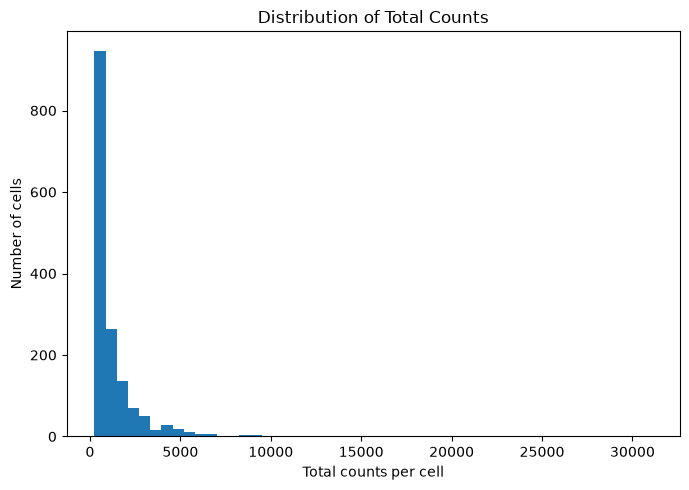

In [24]:
# QC histograms

plt.figure(figsize=(7, 5))
plt.hist(
    adata.obs["total_counts"],
    bins=50
)
plt.xlabel("Total counts per cell")
plt.ylabel("Number of cells")
plt.title("Distribution of Total Counts")
plt.tight_layout()
plt.show()

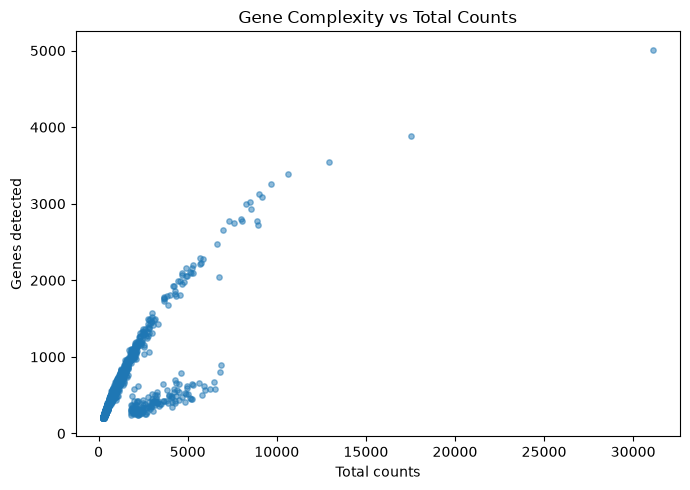

In [25]:
# QC relationship between gene complexity and mitochondrial content

plt.figure(figsize=(7, 5))

plt.scatter(
    adata.obs["total_counts"],
    adata.obs["n_genes_by_counts"],
    s=15,
    alpha=0.5
)

plt.xlabel("Total counts")
plt.ylabel("Genes detected")
plt.title("Gene Complexity vs Total Counts")

plt.tight_layout()
plt.show()

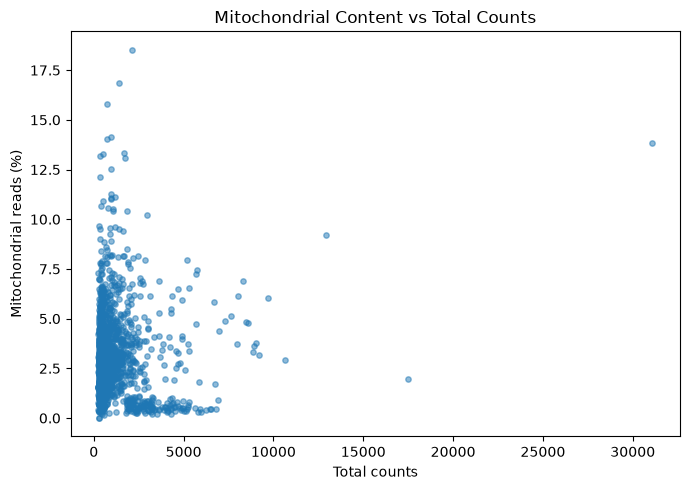

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(
    adata.obs["total_counts"],
    adata.obs["pct_counts_mt"],
    s=15,
    alpha=0.5
)

plt.xlabel("Total counts")
plt.ylabel("Mitochondrial reads (%)")
plt.title("Mitochondrial Content vs Total Counts")

plt.tight_layout()
plt.show()

In [27]:
# Evaluate candidate QC thresholds

low_gene_mask = adata.obs["n_genes_by_counts"] < 200
high_gene_mask = adata.obs["n_genes_by_counts"] >= 3000
high_mito_mask = adata.obs["pct_counts_mt"] >= 10

print("Total cells:", adata.n_obs)

print(
    "Cells with < 200 genes:",
    low_gene_mask.sum()
)

print(
    "Cells with >= 3000 genes:",
    high_gene_mask.sum()
)

print(
    "Cells with >= 10% mitochondrial reads:",
    high_mito_mask.sum()
)

combined_fail = (
    low_gene_mask
    | high_gene_mask
    | high_mito_mask
)

print(
    "\nCells failing at least one QC criterion:",
    combined_fail.sum()
)

print(
    "Cells retained:",
    (~combined_fail).sum()
)

Total cells: 1564
Cells with < 200 genes: 0
Cells with >= 3000 genes: 8
Cells with >= 10% mitochondrial reads: 23

Cells failing at least one QC criterion: 30
Cells retained: 1534


In [28]:
# Apply QC filtering

adata_qc = adata[
    (adata.obs["n_genes_by_counts"] >= 200)
    & (adata.obs["n_genes_by_counts"] < 3000)
    & (adata.obs["pct_counts_mt"] < 10)
].copy()

print("Cells before QC:", adata.n_obs)
print("Cells after QC:", adata_qc.n_obs)
print("Cells removed:", adata.n_obs - adata_qc.n_obs)

print("\nGenes before gene filtering:", adata_qc.n_vars)

Cells before QC: 1564
Cells after QC: 1534
Cells removed: 30

Genes before gene filtering: 29733


In [29]:
# Keep genes detected in at least 3 cells

sc.pp.filter_genes(
    adata_qc,
    min_cells=3
)

print("Genes after filtering:", adata_qc.n_vars)

Genes after filtering: 13514


In [30]:
print("=== POST-QC SUMMARY ===")

print("Cells:", adata_qc.n_obs)
print("Genes:", adata_qc.n_vars)

print("\nGenes detected per cell:")
print(
    adata_qc.obs["n_genes_by_counts"].describe()
)

print("\nMitochondrial percentage:")
print(
    adata_qc.obs["pct_counts_mt"].describe()
)

print("\nCell-type major distribution:")
print(
    adata_qc.obs["celltype_major"].value_counts()
)

=== POST-QC SUMMARY ===
Cells: 1534
Genes: 13514

Genes detected per cell:
count    1534.000000
mean      529.966754
std       384.288125
min       201.000000
25%       295.000000
50%       405.500000
75%       614.750000
max      2991.000000
Name: n_genes_by_counts, dtype: float64

Mitochondrial percentage:
count    1534.000000
mean        3.012044
std         1.790600
min         0.000000
25%         1.714636
50%         2.760736
75%         3.965517
max         9.677419
Name: pct_counts_mt, dtype: float64

Cell-type major distribution:
celltype_major
CAFs                 376
PVL                  314
Endothelial          285
Myeloid              178
T-cells              116
Cancer Epithelial    113
Plasmablasts         110
B-cells               33
Normal Epithelial      9
Name: count, dtype: int64


In [31]:
# Preserve raw count matrix before normalization

adata_qc.layers["counts"] = adata_qc.X.copy()

print("Raw counts stored in adata_qc.layers['counts']")

Raw counts stored in adata_qc.layers['counts']


In [32]:
# Normalize total counts per cell

sc.pp.normalize_total(
    adata_qc,
    target_sum=1e4
)

print("Normalization complete.")

Normalization complete.


In [33]:
# Log-transform normalized expression

sc.pp.log1p(adata_qc)

print("Log1p transformation complete.")

Log1p transformation complete.


In [34]:
# Identify highly variable genes

sc.pp.highly_variable_genes(
    adata_qc,
    n_top_genes=2000,
    flavor="seurat"
)

print(
    "Highly variable genes:",
    adata_qc.var["highly_variable"].sum()
)

Highly variable genes: 2000


In [35]:
# Inspect highly variable genes

hvg_table = (
    adata_qc.var[
        adata_qc.var["highly_variable"]
    ][
        [
            "means",
            "dispersions",
            "dispersions_norm"
        ]
    ]
    .sort_values(
        "dispersions_norm",
        ascending=False
    )
)

display(hvg_table.head(20))

,means,dispersions,dispersions_norm
CCL21,0.716771,5.983294,13.127837
IGHA2,0.311376,4.824329,10.447152
IGHG4,1.140707,6.015987,8.843137
CCR7,0.372193,4.361961,7.912690
IGHG2,1.557488,6.906220,7.817193
GNLY,0.715998,4.710141,7.615308
IFIT2,0.470405,4.254308,7.322596
MMP9,0.956527,5.414868,7.062350
STC1,0.556297,4.139222,6.691755
MMP1,0.595087,4.108546,6.523602


In [36]:
# Create HVG-only object for dimensionality reduction

adata_hvg = adata_qc[
    :,
    adata_qc.var["highly_variable"]
].copy()

print(adata_hvg)

AnnData object with n_obs × n_vars = 1534 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: None (.X), 'counts'


In [37]:
# Scale highly variable genes

sc.pp.scale(
    adata_hvg,
    max_value=10
)

print("Scaling complete.")

Scaling complete.


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [40]:
# Principal component analysis

sc.tl.pca(
    adata_hvg,
    n_comps=50,
    svd_solver="arpack"
)

print("PCA complete.")
print("PCA coordinates shape:", adata_hvg.obsm["X_pca"].shape)

PCA complete.
PCA coordinates shape: (1534, 50)


In [42]:
# Extract PCA explained variance

pca_variance = adata_hvg.uns["pca"]["variance_ratio"]

print("First 10 PCs:")

for i, value in enumerate(pca_variance[:10], start=1):
    print(f"PC{i}: {value * 100:.2f}%")

First 10 PCs:
PC1: 1.65%
PC2: 1.16%
PC3: 0.96%
PC4: 0.89%
PC5: 0.64%
PC6: 0.57%
PC7: 0.54%
PC8: 0.42%
PC9: 0.34%
PC10: 0.32%


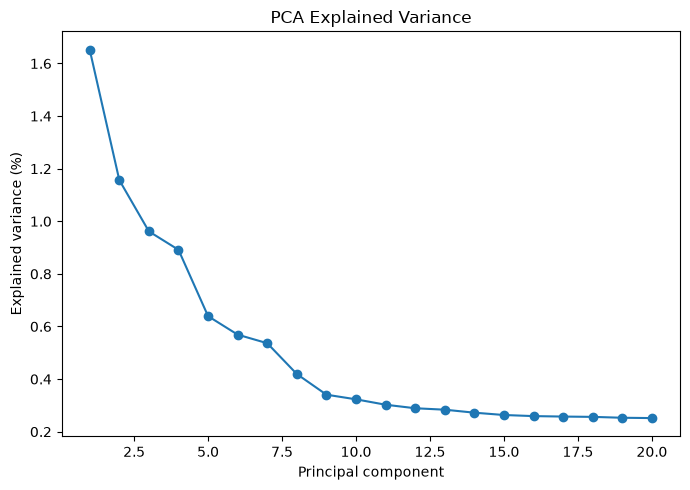

In [43]:
# PCA scree plot

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, 21),
    pca_variance[:20] * 100,
    marker="o"
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA Explained Variance")

plt.tight_layout()
plt.show()

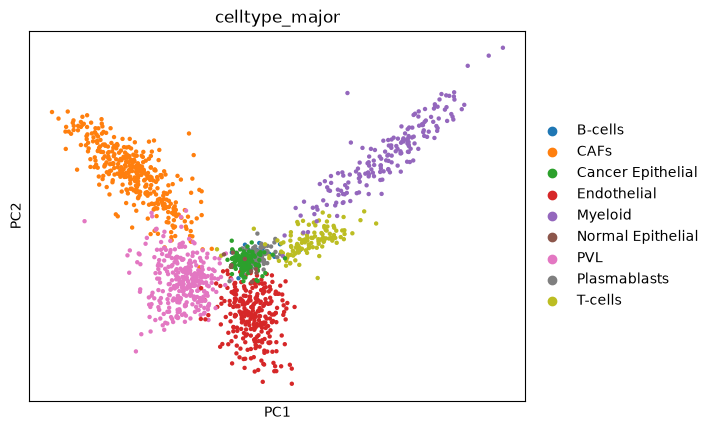

In [44]:
# PCA coloured by author-provided major cell type

sc.pl.pca(
    adata_hvg,
    color="celltype_major",
    size=40
)

In [45]:
# Build nearest-neighbour graph

sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=15
)

print("Neighbour graph constructed.")

/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbour graph constructed.


In [46]:
# Compute UMAP

sc.tl.umap(
    adata_hvg,
    random_state=42
)

print("UMAP complete.")
print("UMAP coordinates shape:", adata_hvg.obsm["X_umap"].shape)

UMAP complete.
UMAP coordinates shape: (1534, 2)


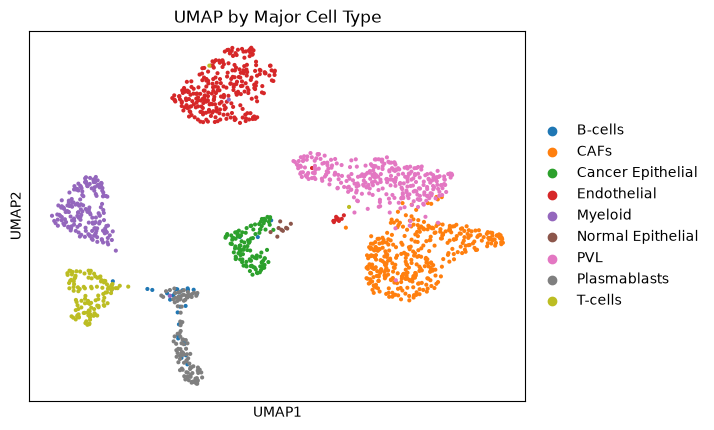

In [47]:
# UMAP coloured by author-provided major cell type

sc.pl.umap(
    adata_hvg,
    color="celltype_major",
    size=35,
    title="UMAP by Major Cell Type"
)

In [50]:
# Leiden clustering

sc.tl.leiden(
    adata_hvg,
    resolution=0.5,
    key_added="leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False
)

print("Leiden clustering complete.")

print("\nCluster distribution:")
print(
    adata_hvg.obs["leiden"]
    .value_counts()
    .sort_index()
)

Leiden clustering complete.

Cluster distribution:
leiden
0    277
1    317
2    152
3    232
4    125
5     57
6     82
7    116
8    176
Name: count, dtype: int64


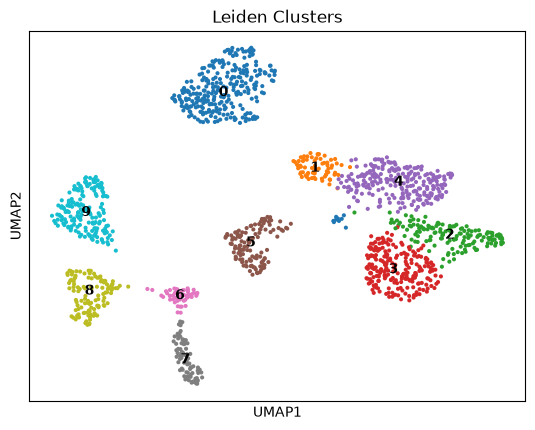

In [55]:
sc.pl.umap(
    adata_hvg,
    color="leiden",
    legend_loc="on data",
    size=35,
    title="Leiden Clusters"
)

In [56]:
cluster_celltype_table = pd.crosstab(
    adata_hvg.obs["leiden"],
    adata_hvg.obs["celltype_major"]
)

display(cluster_celltype_table)

celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
leiden,,,,,,,,,
0,0,1,0,284,1,0,0,0,1
1,0,0,0,1,0,0,70,0,0
2,0,141,0,0,0,0,7,0,0
3,0,225,0,0,0,0,1,0,0
4,0,9,0,0,0,0,236,0,1
5,3,0,113,0,0,9,0,0,0
6,21,0,0,0,1,0,0,35,0
7,8,0,0,0,0,0,0,74,0
8,1,0,0,0,0,0,0,1,114


In [53]:
sc.tl.leiden(
    adata_hvg,
    resolution=0.5,
    key_added="leiden",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42
)

In [54]:
print(
    adata_hvg.obs["leiden"]
    .value_counts()
    .sort_index()
)

leiden
0    287
1     71
2    148
3    226
4    246
5    125
6     57
7     82
8    116
9    176
Name: count, dtype: int64


In [57]:
# Identify marker genes for each Leiden cluster

sc.tl.rank_genes_groups(
    adata_hvg,
    groupby="leiden",
    method="wilcoxon",
    key_added="leiden_markers"
)

print("Marker gene analysis complete.")

Marker gene analysis complete.


/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/opt/anaconda3/envs/cancer-informatics/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:633: RuntimeWarning: invalid value encountered in

In [58]:
# Display top marker genes for each cluster

marker_df = sc.get.rank_genes_groups_df(
    adata_hvg,
    group=None,
    key="leiden_markers"
)

print("Marker result shape:", marker_df.shape)

display(marker_df.head(20))

Marker result shape: (20000, 6)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,PLVAP,16.770248,NaN,4.028239e-63,8.056478e-60
1,0,CD74,15.316085,NaN,5.970753e-53,5.970753e-50
2,0,HYAL2,12.485794,NaN,8.924859e-36,5.949906e-33
3,0,VWF,11.925721,NaN,8.692759e-33,4.346379e-30
4,0,ACKR1,11.441690,NaN,2.587943e-30,1.035177e-27
5,0,CLEC14A,9.886065,NaN,4.784676e-23,1.594892e-20
6,0,AQP1,9.461817,NaN,3.026384e-21,8.646811e-19
7,0,TSPAN7,9.313725,NaN,1.234256e-20,2.742790e-18
8,0,FABP4,8.706506,NaN,3.133851e-18,5.697911e-16
9,0,SPRY1,8.541197,NaN,1.328392e-17,2.213986e-15


In [59]:
# Top 10 marker genes per cluster

for cluster in sorted(
    adata_hvg.obs["leiden"].unique(),
    key=int
):
    top_genes = (
        marker_df[
            marker_df["group"] == cluster
        ]
        .head(10)["names"]
        .tolist()
    )

    print(
        f"Cluster {cluster}:",
        ", ".join(top_genes)
    )

Cluster 0: PLVAP, CD74, HYAL2, VWF, ACKR1, CLEC14A, AQP1, TSPAN7, FABP4, SPRY1
Cluster 1: TAGLN, ADIRF, MYL9, CRYAB, RERGL, SNCG, SORBS2, PTP4A3, PPP1R14A, C12orf75
Cluster 2: LUM, SFRP2, C1R, SFRP4, APOD, MGP, CCDC80, CXCL14, C3, MFAP4
Cluster 3: COL1A1, CTHRC1, LUM, COL1A2, COL3A1, POSTN, SFRP2, FN1, MFAP2, SPARC
Cluster 4: NDUFA4L2, COL18A1, PTP4A3, RGS5, SPARC, MYL9, TIMP1, FRZB, MAP3K7CL, SEPT4
Cluster 5: MT-CO2, FABP7, CENPW, CSN3, CLU, FDCSP, CLDN4, ODAM, RARRES1, MMP7
Cluster 6: JCHAIN, IGHA1, IGKC, IGHA2, IGHM, IGLC3, RGCC, IL2RG, CCL4, PRDM1
Cluster 7: IGHG3, IGHG1, IGHGP, IGHG4, IGHG2, JCHAIN, IGLC3, IGLL1, IGKC, IGHM
Cluster 8: CD52, TRAC, CD3D, IL32, CD2, TRBC2, LTB, IL2RG, RGCC, LCK
Cluster 9: HLA-DRA, CD74, FTL, HLA-DRB5, LYZ, FCER1G, HLA-DPB1, AIF1, HLA-DQB1, MS4A6A


In [60]:
cluster_to_celltype = {
    "0": "Endothelial",
    "1": "PVL",
    "2": "CAFs",
    "3": "CAFs",
    "4": "PVL",
    "5": "Cancer Epithelial",
    "6": "B/Plasmablast",
    "7": "Plasmablasts",
    "8": "T-cells",
    "9": "Myeloid"
}

adata_hvg.obs["predicted_celltype"] = (
    adata_hvg.obs["leiden"]
    .map(cluster_to_celltype)
)

print(
    adata_hvg.obs["predicted_celltype"]
    .value_counts()
)

predicted_celltype
CAFs                 374
PVL                  317
Endothelial          287
Myeloid              176
Cancer Epithelial    125
T-cells              116
Plasmablasts          82
B/Plasmablast         57
Name: count, dtype: int64


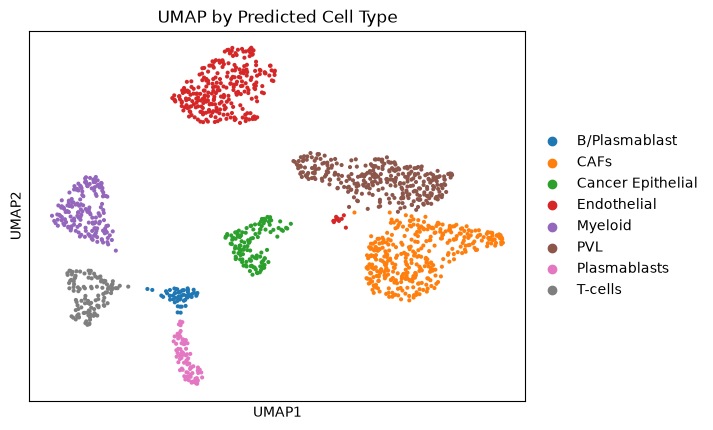

In [61]:
sc.pl.umap(
    adata_hvg,
    color="predicted_celltype",
    size=35,
    title="UMAP by Predicted Cell Type"
)

In [62]:
annotation_comparison = pd.crosstab(
    adata_hvg.obs["predicted_celltype"],
    adata_hvg.obs["celltype_major"]
)

display(annotation_comparison)

celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
predicted_celltype,,,,,,,,,
B/Plasmablast,21,0,0,0,1,0,0,35,0
CAFs,0,366,0,0,0,0,8,0,0
Cancer Epithelial,3,0,113,0,0,9,0,0,0
Endothelial,0,1,0,284,1,0,0,0,1
Myeloid,0,0,0,0,176,0,0,0,0
PVL,0,9,0,1,0,0,306,0,1
Plasmablasts,8,0,0,0,0,0,0,74,0
T-cells,1,0,0,0,0,0,0,1,114


In [63]:
marker_panel = {
    "Endothelial": ["VWF", "PLVAP", "ACKR1"],
    "PVL": ["RGS5", "TAGLN", "MYL9"],
    "CAFs": ["COL1A1", "COL1A2", "LUM"],
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T cells": ["CD3D", "CD3E", "TRAC"],
    "Myeloid": ["LYZ", "FCER1G", "AIF1"],
    "B cells": ["CD79A", "MS4A1", "CD74"],
    "Plasmablasts": ["JCHAIN", "MZB1", "PRDM1"]
}

In [68]:
marker_panel = {
    "Endothelial": ["VWF", "PLVAP", "ACKR1"],
    "PVL": ["RGS5", "TAGLN", "MYL9"],
    "CAFs": ["COL1A1", "COL1A2", "LUM"],
    "Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "T cells": ["CD3D", "CD3E", "TRAC"],
    "Myeloid": ["LYZ", "FCER1G", "AIF1"],
    "B cells": ["CD79A", "CD74"],
    "Plasmablasts": ["JCHAIN", "MZB1", "PRDM1"]
}

In [65]:
# Transfer clustering and UMAP results to the full-gene object

adata_qc.obs["leiden"] = adata_hvg.obs["leiden"].copy()
adata_qc.obs["predicted_celltype"] = (
    adata_hvg.obs["predicted_celltype"].copy()
)

adata_qc.obsm["X_umap"] = adata_hvg.obsm["X_umap"].copy()

print("Clustering metadata transferred.")

Clustering metadata transferred.


In [66]:
available_markers_full = [
    gene for gene in marker_genes
    if gene in adata_qc.var_names
]

missing_markers_full = [
    gene for gene in marker_genes
    if gene not in adata_qc.var_names
]

print("Available markers in full expression object:")
print(available_markers_full)

print("\nMissing markers:")
print(missing_markers_full)

Available markers in full expression object:
['VWF', 'PLVAP', 'ACKR1', 'RGS5', 'TAGLN', 'MYL9', 'COL1A1', 'COL1A2', 'LUM', 'EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CD3D', 'CD3E', 'TRAC', 'LYZ', 'FCER1G', 'AIF1', 'CD79A', 'CD74', 'JCHAIN', 'MZB1', 'PRDM1']

Missing markers:
['MS4A1']


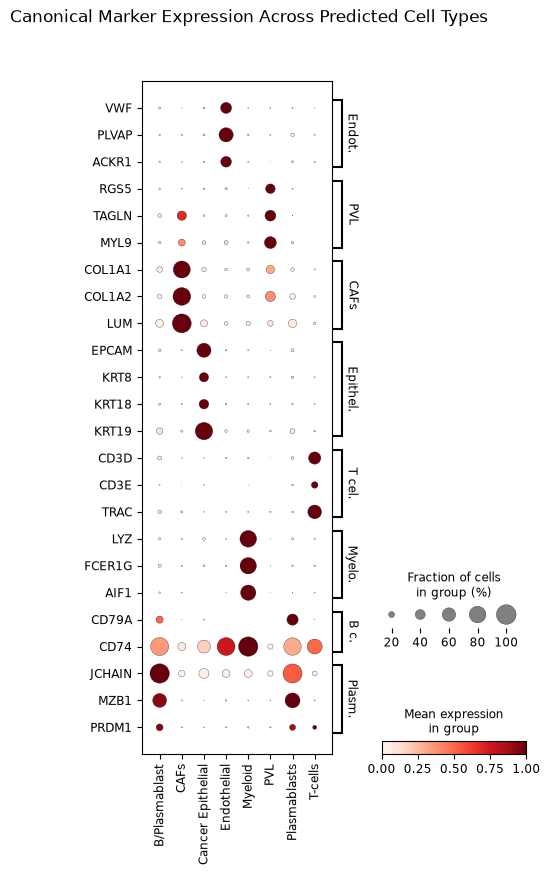

In [69]:
sc.pl.dotplot(
    adata_qc,
    marker_panel,
    groupby="predicted_celltype",
    standard_scale="var",
    swap_axes=True,
    title="Canonical Marker Expression Across Predicted Cell Types"
)

In [70]:
# Cell-type composition

celltype_counts = (
    adata_hvg.obs["predicted_celltype"]
    .value_counts()
)

celltype_percent = (
    celltype_counts / adata_hvg.n_obs * 100
)

composition_df = pd.DataFrame({
    "cell_count": celltype_counts,
    "percentage": celltype_percent
})

composition_df = composition_df.sort_values(
    "cell_count",
    ascending=False
)

display(composition_df.round(2))

,cell_count,percentage
predicted_celltype,,
CAFs,374,24.38
PVL,317,20.66
Endothelial,287,18.71
Myeloid,176,11.47
Cancer Epithelial,125,8.15
T-cells,116,7.56
Plasmablasts,82,5.35
B/Plasmablast,57,3.72


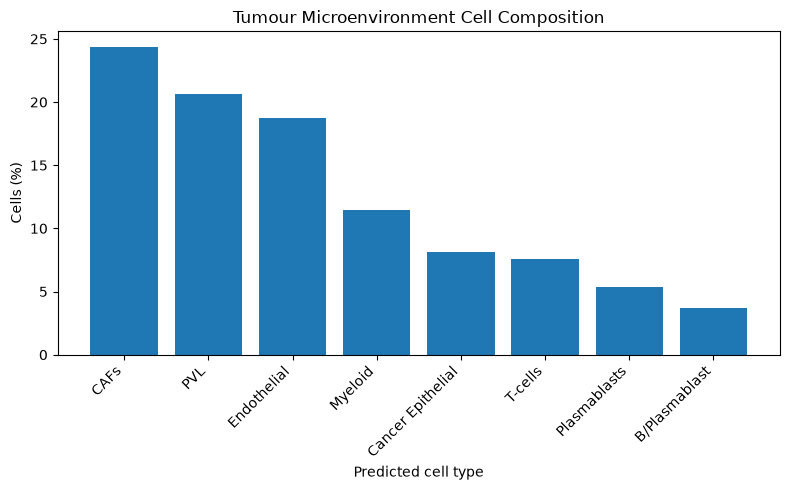

In [71]:
plt.figure(figsize=(8, 5))

plt.bar(
    composition_df.index,
    composition_df["percentage"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cells (%)")
plt.xlabel("Predicted cell type")
plt.title("Tumour Microenvironment Cell Composition")

plt.tight_layout()
plt.show()

In [72]:
composition_path = (
    results_dir / "01_CID4465_celltype_composition.csv"
)

composition_df.to_csv(composition_path)

print("Saved cell-type composition to:")
print(composition_path)

Saved cell-type composition to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/results/01_CID4465_celltype_composition.csv


In [73]:
# Group predicted cell types into major TME compartments

compartment_map = {
    "CAFs": "Stromal",
    "PVL": "Stromal",
    "Endothelial": "Stromal",

    "Myeloid": "Immune",
    "T-cells": "Immune",
    "Plasmablasts": "Immune",
    "B/Plasmablast": "Immune",

    "Cancer Epithelial": "Epithelial"
}

adata_hvg.obs["tme_compartment"] = (
    adata_hvg.obs["predicted_celltype"]
    .map(compartment_map)
)

print(
    adata_hvg.obs["tme_compartment"]
    .value_counts()
)

tme_compartment
Stromal       978
Immune        431
Epithelial    125
Name: count, dtype: int64


In [74]:
# Major TME compartment composition

compartment_counts = (
    adata_hvg.obs["tme_compartment"]
    .value_counts()
)

compartment_percent = (
    compartment_counts / adata_hvg.n_obs * 100
)

compartment_df = pd.DataFrame({
    "cell_count": compartment_counts,
    "percentage": compartment_percent
})

display(compartment_df.round(2))

,cell_count,percentage
tme_compartment,,
Stromal,978,63.75
Immune,431,28.10
Epithelial,125,8.15


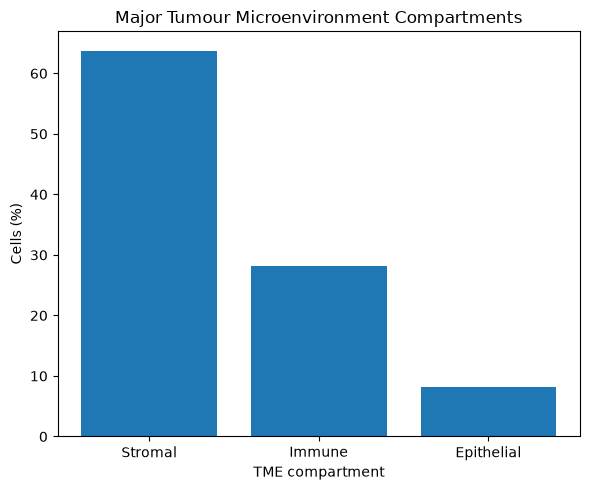

In [75]:
plt.figure(figsize=(6, 5))

plt.bar(
    compartment_df.index,
    compartment_df["percentage"]
)

plt.ylabel("Cells (%)")
plt.xlabel("TME compartment")
plt.title("Major Tumour Microenvironment Compartments")

plt.tight_layout()
plt.show()

In [76]:
compartment_path = (
    results_dir / "01_CID4465_tme_compartments.csv"
)

compartment_df.to_csv(compartment_path)

print("Saved TME compartment results to:")
print(compartment_path)

Saved TME compartment results to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/results/01_CID4465_tme_compartments.csv


In [77]:
# Final QC for Project 02 Notebook 01

print("=== FINAL SINGLE-CELL DATA LOADING & QC SUMMARY ===")

print(f"Sample: CID4465")
print(f"Breast cancer subtype: TNBC")

print(f"\nCells before QC: {adata.n_obs}")
print(f"Cells after QC: {adata_qc.n_obs}")
print(f"Cells removed: {adata.n_obs - adata_qc.n_obs}")

print(f"\nGenes before filtering: {adata.n_vars}")
print(f"Genes after filtering: {adata_qc.n_vars}")
print(f"Highly variable genes: {adata_hvg.n_vars}")

print("\nLeiden clusters:")
print(
    adata_hvg.obs["leiden"]
    .value_counts()
    .sort_index()
)

print("\nPredicted cell types:")
print(
    adata_hvg.obs["predicted_celltype"]
    .value_counts()
)

print("\nTME compartments:")
print(
    compartment_df.round(2)
)

=== FINAL SINGLE-CELL DATA LOADING & QC SUMMARY ===
Sample: CID4465
Breast cancer subtype: TNBC

Cells before QC: 1564
Cells after QC: 1534
Cells removed: 30

Genes before filtering: 29733
Genes after filtering: 13514
Highly variable genes: 2000

Leiden clusters:
leiden
0    287
1     71
2    148
3    226
4    246
5    125
6     57
7     82
8    116
9    176
Name: count, dtype: int64

Predicted cell types:
predicted_celltype
CAFs                 374
PVL                  317
Endothelial          287
Myeloid              176
Cancer Epithelial    125
T-cells              116
Plasmablasts          82
B/Plasmablast         57
Name: count, dtype: int64

TME compartments:
                 cell_count  percentage
tme_compartment                        
Stromal                 978       63.75
Immune                  431       28.10
Epithelial              125        8.15


In [78]:
processed_file = (
    processed_dir / "CID4465_processed.h5ad"
)

adata_qc.write(processed_file)

print("Saved processed AnnData to:")
print(processed_file)

Saved processed AnnData to:
/Users/zeyuliu/Projects/Cancer-Informatics-Portfolio/02_BRCA_Single_Cell_TME/data/processed/CID4465_processed.h5ad
